In [2]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df=pd.read_csv("Car Dataset.csv")
(df)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
2,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
3,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?
4,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,13415
207,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,24,28,16515
208,-1,74,volvo,gas,turbo,four,wagon,rwd,front,104.3,...,130,mpfi,3.62,3.15,7.5,162,5100,17,22,18950
209,-1,74,volvo,gas,std,four,wagon,rwd,front,104.3,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,13415


In [4]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
2,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
3,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.4,7.0,160,5500,16,22,?
4,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.4,8.5,110,5500,19,25,17710


In [47]:
categorical_columns = ["make",'fuel-type','aspiration','num-of-doors','body-style','drive-wheels','engine-location']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211 entries, 0 to 210
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          211 non-null    int64  
 1   normalized-losses  211 non-null    object 
 2   make               211 non-null    object 
 3   fuel-type          211 non-null    object 
 4   aspiration         211 non-null    object 
 5   num-of-doors       211 non-null    object 
 6   body-style         211 non-null    object 
 7   drive-wheels       211 non-null    object 
 8   engine-location    211 non-null    object 
 9   wheel-base         211 non-null    float64
 10  length             211 non-null    float64
 11  width              211 non-null    float64
 12  height             211 non-null    float64
 13  curb-weight        211 non-null    int64  
 14  engine-type        211 non-null    object 
 15  num-of-cylinders   211 non-null    object 
 16  engine-size        211 non

In [6]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
206    False
207    False
208    False
209     True
210     True
Length: 211, dtype: bool

In [7]:
duplicates=df.duplicated(keep=False)
num_duplicated=duplicates.sum()
print(num_duplicated)

12


In [8]:
from scipy import stats
from scipy.stats import zscore

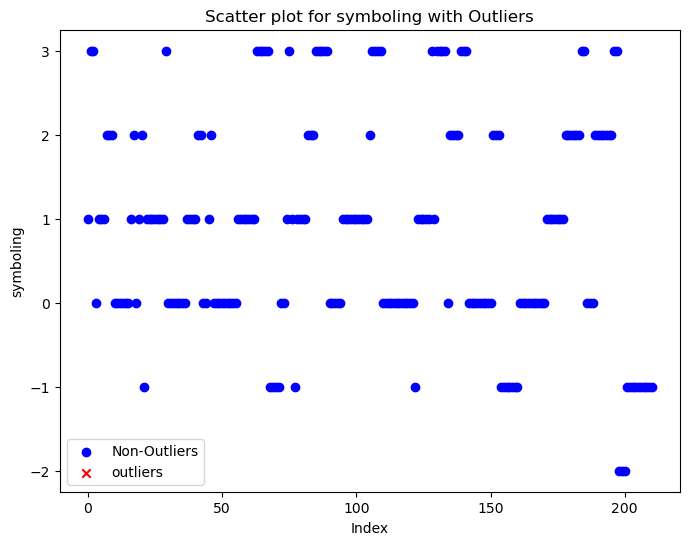

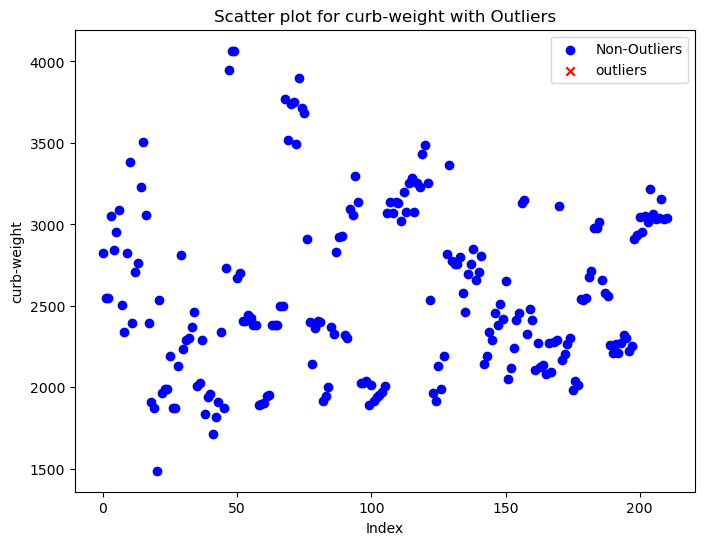

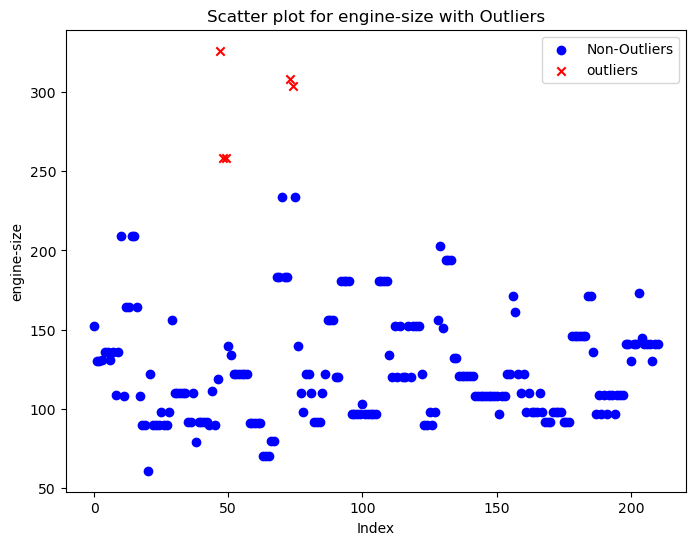

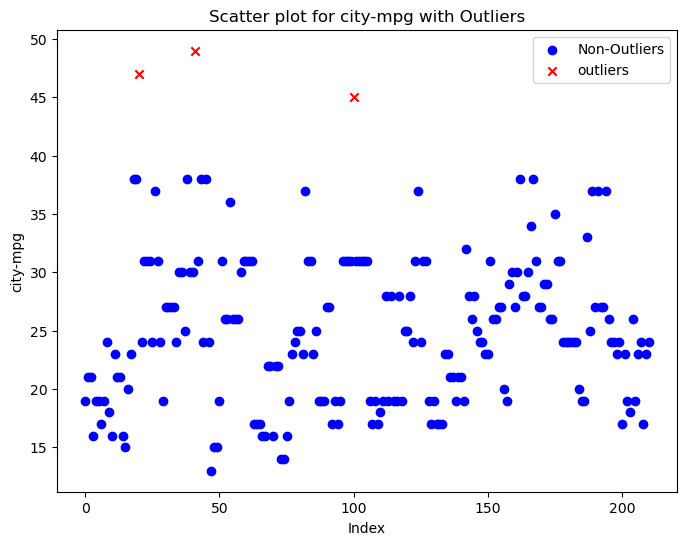

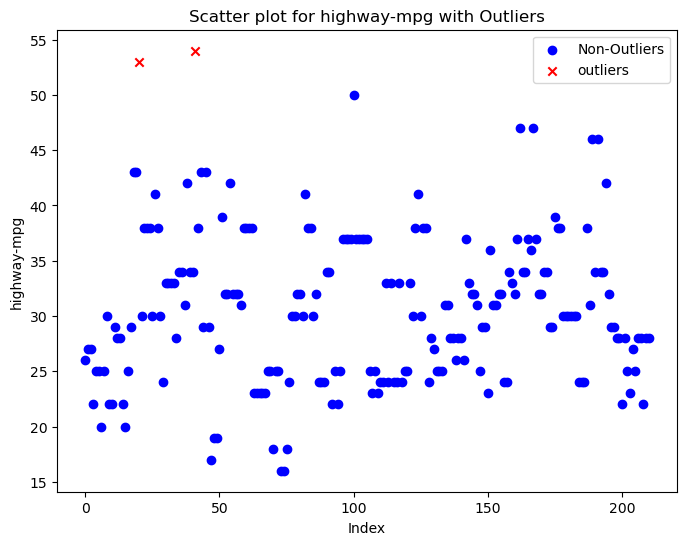

In [9]:
numeric_cols=["symboling","curb-weight","engine-size","city-mpg","highway-mpg"]
z_scores = np.abs((df[numeric_cols]-df[numeric_cols].mean())/df[numeric_cols].std())
z_score_threshold = 3
outlier_mask=z_scores>z_score_threshold
for col in numeric_cols:
    plt.figure(figsize=(8, 6))
    plt.scatter(df.index[~outlier_mask[col]],df[col][~outlier_mask[col]], marker='o', label='Non-Outliers', color='blue')
    plt.scatter(df.index[outlier_mask[col]],df[col][outlier_mask[col]], marker='x', label='outliers',color='red')
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.title(f'Scatter plot for {col} with Outliers')
    plt.legend()
    plt.show()

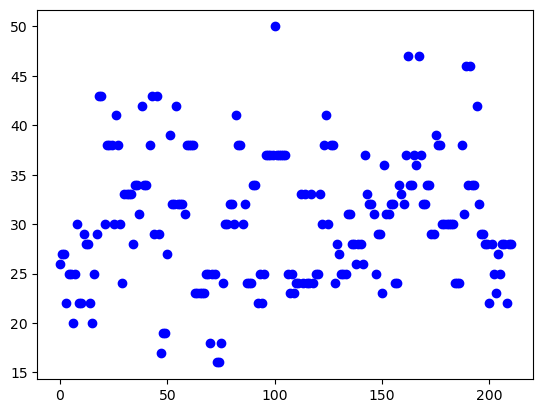

In [11]:
plt.scatter(df.index[~outlier_mask[col]],df[col][~outlier_mask[col]],marker='o',label='Non-outliers',color='blue')

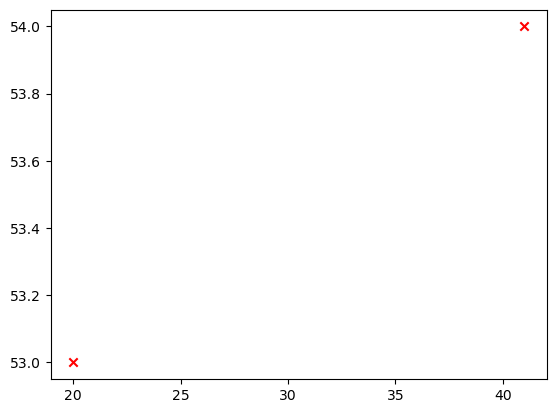

In [12]:
plt.scatter(df.index[outlier_mask[col]],df[col][outlier_mask[col]],marker='x',label='Outliers',color='red')

In [23]:
df=df.drop(df.index[outlier_mask[col]])

In [25]:
missing_value=df.isnull().sum()
missing_value

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [30]:
df.count()

symboling            209
normalized-losses    209
make                 209
fuel-type            209
aspiration           209
num-of-doors         209
body-style           209
drive-wheels         209
engine-location      209
wheel-base           209
length               209
width                209
height               209
curb-weight          209
engine-type          209
num-of-cylinders     209
engine-size          209
fuel-system          209
bore                 209
stroke               209
compression-ratio    209
horsepower           209
peak-rpm             209
city-mpg             209
highway-mpg          209
price                209
dtype: int64

In [34]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,0.832536,98.873206,174.493301,65.986603,53.733493,2577.645933,127.937799,10.173780,24.885167,30.416268
std,1.269348,5.967754,11.949330,2.102588,2.496118,513.819557,41.431953,4.009408,6.152409,6.500290
min,-2.000000,86.600000,144.600000,61.800000,47.800000,1819.000000,70.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,167.300000,64.200000,52.000000,2191.000000,98.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2455.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.500000,66.900000,55.600000,2976.000000,146.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,45.000000,50.000000


array([[<Axes: title={'center': 'symboling'}>,
        <Axes: title={'center': 'curb-weight'}>],
       [<Axes: title={'center': 'engine-size'}>,
        <Axes: title={'center': 'city-mpg'}>],
       [<Axes: title={'center': 'highway-mpg'}>, <Axes: >]], dtype=object)

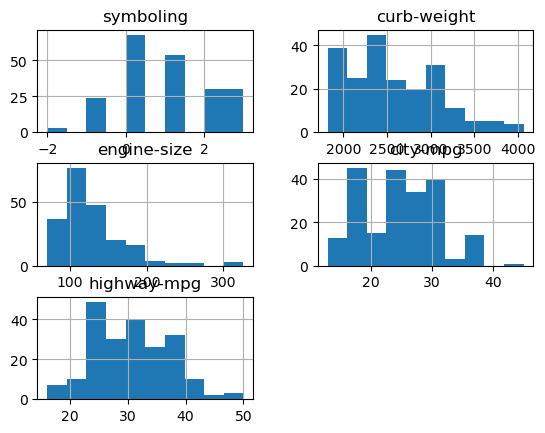

In [36]:
df[numeric_cols].hist()

In [48]:
categorical_columns = ["make",'fuel-type','aspiration','num-of-doors','body-style','drive-wheels','engine-location']

<Axes: >

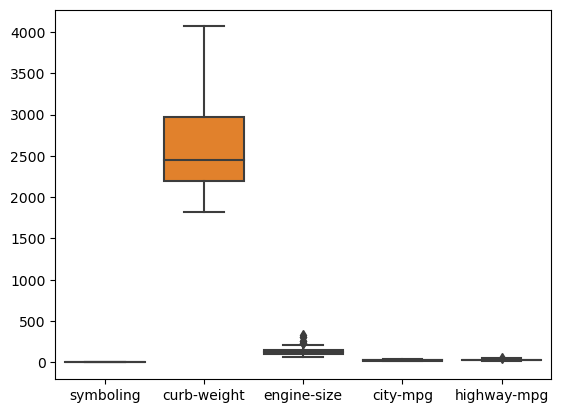

In [53]:
sns.boxplot(data=df[numeric_cols])

{'whiskers': [<matplotlib.lines.Line2D at 0x20e476f5090>,
 'caps': [<matplotlib.lines.Line2D at 0x20e476f6f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e46b56850>],
 'medians': [<matplotlib.lines.Line2D at 0x20e476f7f50>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e476f8410>],
 'means': []}

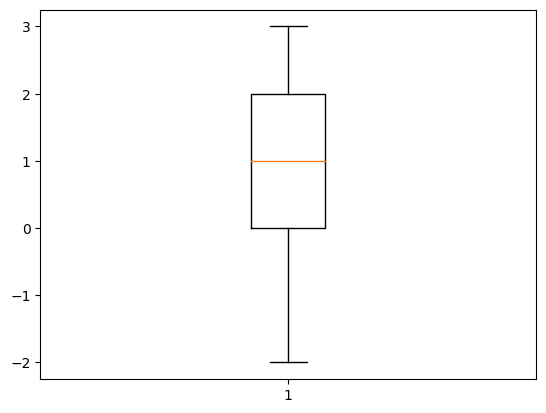

In [62]:
plt.boxplot(df[col].dropna())

{'whiskers': [<matplotlib.lines.Line2D at 0x20e47703b50>,
 'caps': [<matplotlib.lines.Line2D at 0x20e47709390>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e47731550>],
 'medians': [<matplotlib.lines.Line2D at 0x20e47714450>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e476b3350>],
 'means': []}

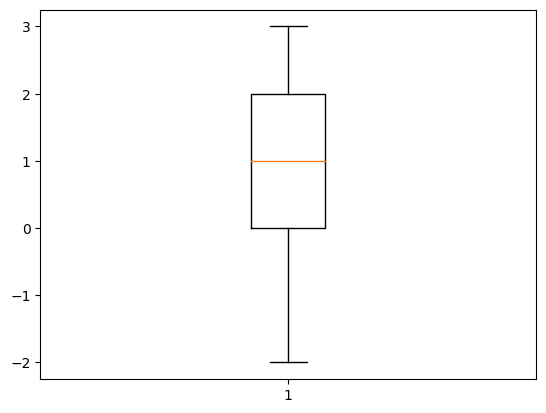

In [64]:
plt.boxplot(df['symboling'].dropna())

{'whiskers': [<matplotlib.lines.Line2D at 0x20e4b6a24d0>,
 'caps': [<matplotlib.lines.Line2D at 0x20e4b6a31d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e4b6a18d0>],
 'medians': [<matplotlib.lines.Line2D at 0x20e4b6a5090>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e4b6a28d0>],
 'means': []}

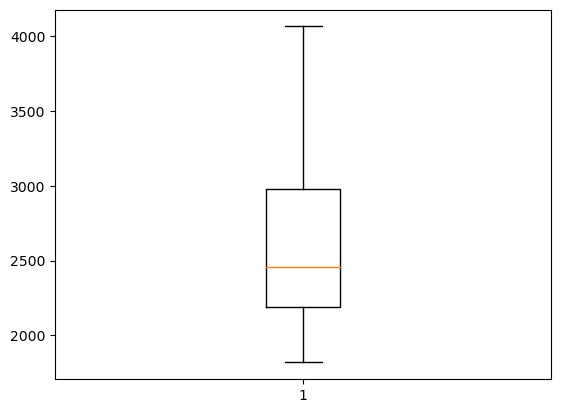

In [66]:
plt.boxplot(df['curb-weight'].dropna())

{'whiskers': [<matplotlib.lines.Line2D at 0x20e4b6d3110>,
 'caps': [<matplotlib.lines.Line2D at 0x20e4b6dc4d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e4b6d2850>],
 'medians': [<matplotlib.lines.Line2D at 0x20e4b6dd3d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e4b6bb710>],
 'means': []}

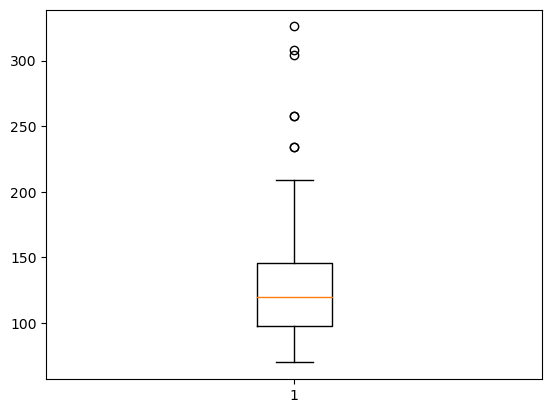

In [67]:
plt.boxplot(df["engine-size"].dropna())

{'whiskers': [<matplotlib.lines.Line2D at 0x20e4b735110>,
 'caps': [<matplotlib.lines.Line2D at 0x20e4b736410>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e4b7347d0>],
 'medians': [<matplotlib.lines.Line2D at 0x20e4b737510>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e4b734fd0>],
 'means': []}

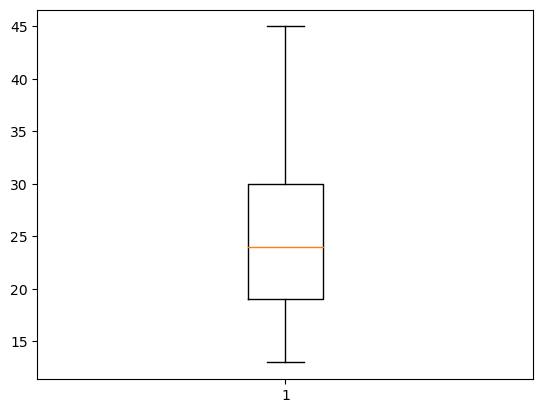

In [68]:
plt.boxplot(df["city-mpg"].dropna())

{'whiskers': [<matplotlib.lines.Line2D at 0x20e4b792950>,
 'caps': [<matplotlib.lines.Line2D at 0x20e4b793b90>,
 'boxes': [<matplotlib.lines.Line2D at 0x20e4b7922d0>],
 'medians': [<matplotlib.lines.Line2D at 0x20e4b7a0c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x20e4b7706d0>],
 'means': []}

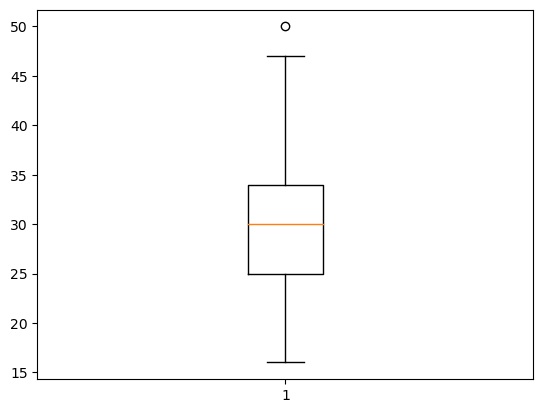

In [69]:
plt.boxplot(df["highway-mpg"].dropna())

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, 'alfa-romero'),
  Text(1, 0, 'audi'),
  Text(2, 0, 'bmw'),
  Text(3, 0, 'chevrolet'),
  Text(4, 0, 'dodge'),
  Text(5, 0, 'honda'),
  Text(6, 0, 'isuzu'),
  Text(7, 0, 'jaguar'),
  Text(8, 0, 'mazda'),
  Text(9, 0, 'mercedes-benz'),
  Text(10, 0, 'mercury'),
  Text(11, 0, 'mitsubishi'),
  Text(12, 0, 'nissan'),
  Text(13, 0, 'peugot'),
  Text(14, 0, 'plymouth'),
  Text(15, 0, 'porsche'),
  Text(16, 0, 'renault'),
  Text(17, 0, 'saab'),
  Text(18, 0, 'subaru'),
  Text(19, 0, 'toyota'),
  Text(20, 0, 'volkswagen'),
  Text(21, 0, 'volvo')])

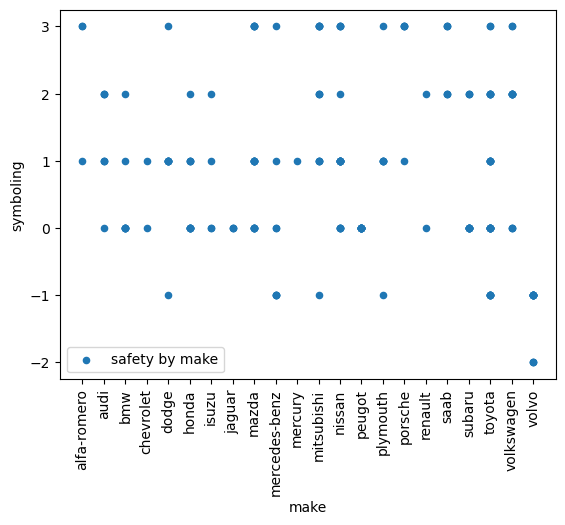

In [72]:
df.plot.scatter(x='make',y='symboling',label='safety by make')
plt.xlabel('make')
plt.ylabel('symboling')
plt.xticks(rotation=90)

In [ ]:
df.plot.scatter(x='make',y='symboling')

<Axes: xlabel='curb-weight', ylabel='symboling'>

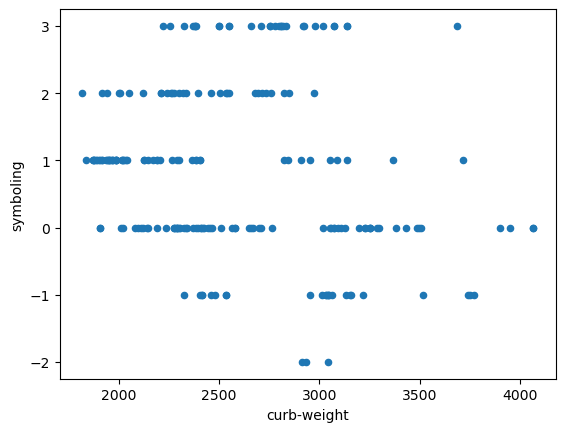

In [73]:
df.plot.scatter(x='curb-weight',y='symboling')

<Axes: xlabel='engine-size', ylabel='symboling'>

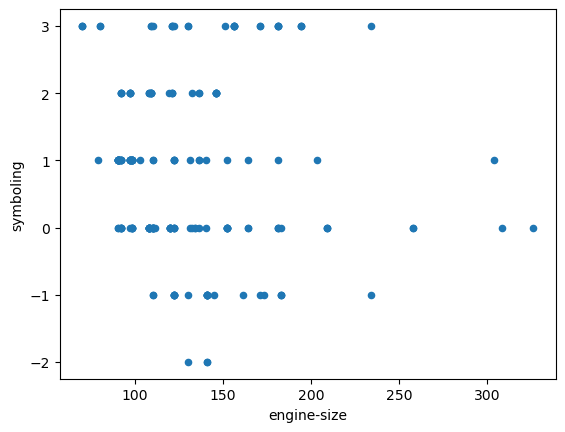

In [74]:
df.plot.scatter(x="engine-size",y='symboling')

<Axes: xlabel='city-mpg', ylabel='symboling'>

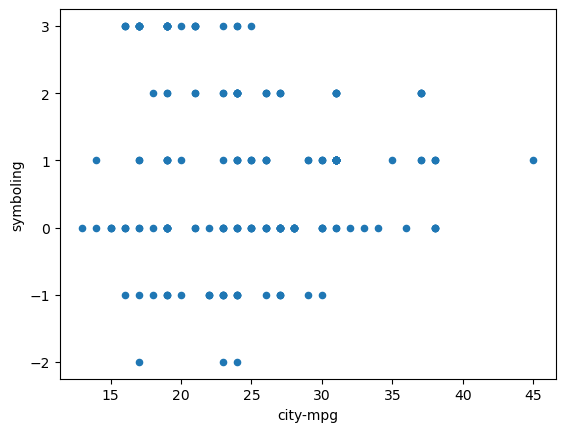

In [75]:
df.plot.scatter(x="city-mpg",y='symboling')

<Axes: xlabel='highway-mpg', ylabel='symboling'>

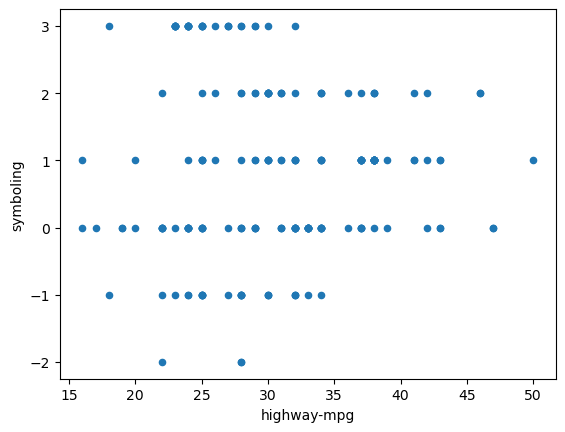

In [76]:
df.plot.scatter(x="highway-mpg",y='symboling')

In [84]:
df[numeric_cols].corr()

,symboling,curb-weight,engine-size,city-mpg,highway-mpg
symboling,1.000000,-0.206208,-0.086038,-0.098511,-0.017731
curb-weight,-0.206208,1.000000,0.847099,-0.743232,-0.786767
engine-size,-0.086038,0.847099,1.000000,-0.647249,-0.672467
city-mpg,-0.098511,-0.743232,-0.647249,1.000000,0.968090
highway-mpg,-0.017731,-0.786767,-0.672467,0.968090,1.000000


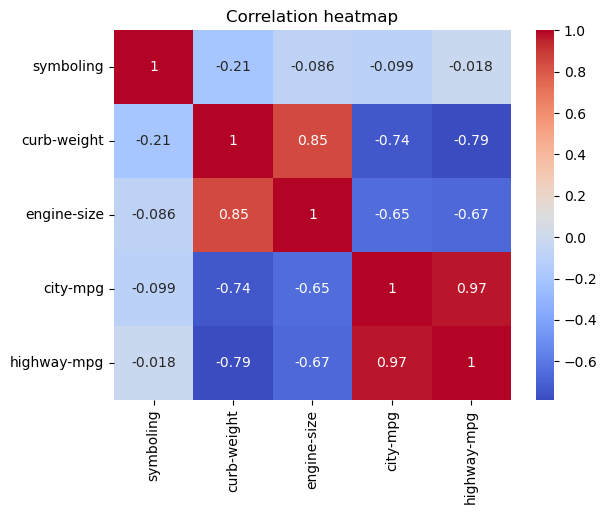

In [122]:
heatmap_corr=df[numeric_cols].corr()
sns.heatmap(heatmap_corr, annot=True, cmap='coolwarm')
plt.title('Correlation heatmap')
plt.show()

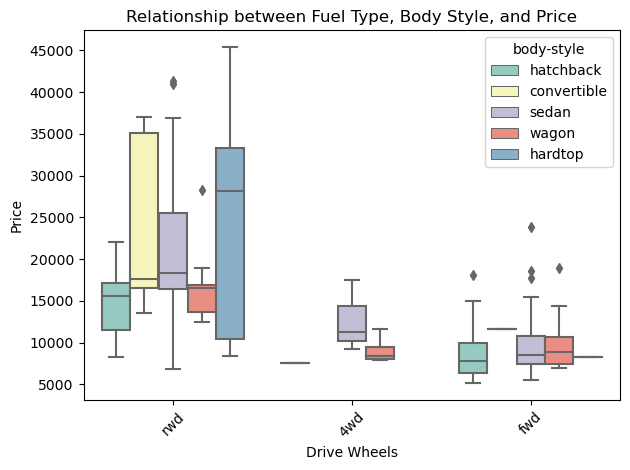

In [100]:
df['price']=pd.to_numeric(df['price'], errors='coerce')
cat_df=df[['drive-wheels', 'body-style', 'price']]
sns.boxplot(x='drive-wheels', y='price', hue='body-style', data=cat_df, palette='Set3')
plt.xlabel('Drive Wheels')
plt.ylabel('Price')
plt.title('Relationship between Fuel Type, Body Style, and Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

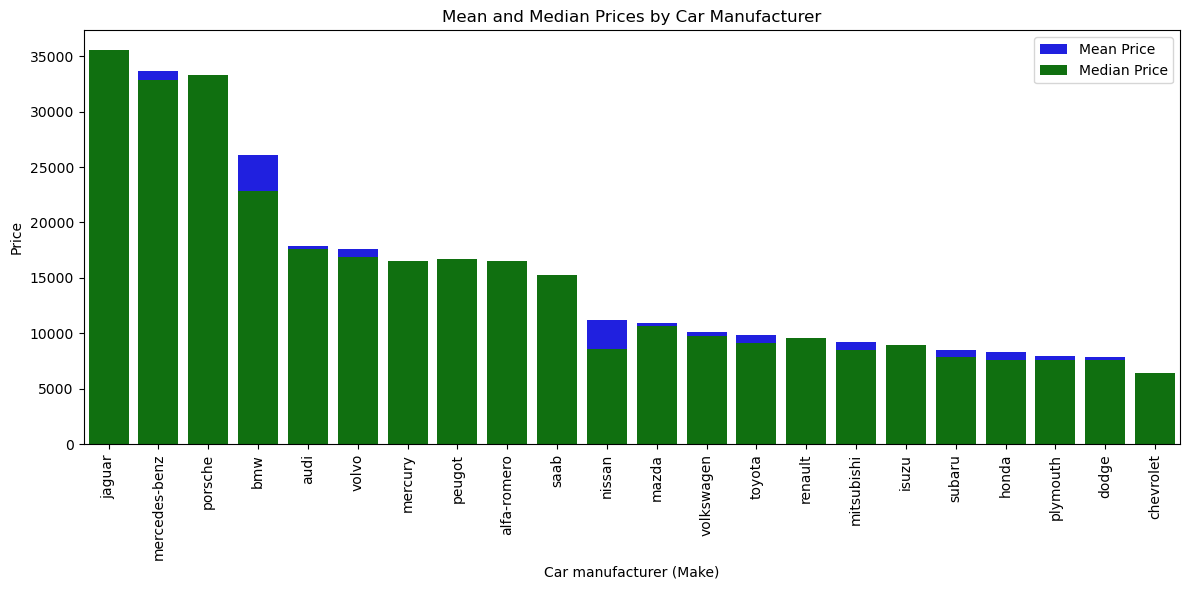

In [117]:
df['price']=pd.to_numeric(df['price'], errors='coerce')
price_stats=df.groupby('make')['price'].agg(['mean','median']).reset_index()
price_stats=price_stats.sort_values(by='mean',ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(data=price_stats, x='make', y='mean', color='blue', label='Mean Price')
sns.barplot(data=price_stats, x='make', y='median', color='green', label='Median Price')
plt.xlabel('Car manufacturer (Make)')
plt.ylabel('Price')
plt.title('Mean and Median Prices by Car Manufacturer')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

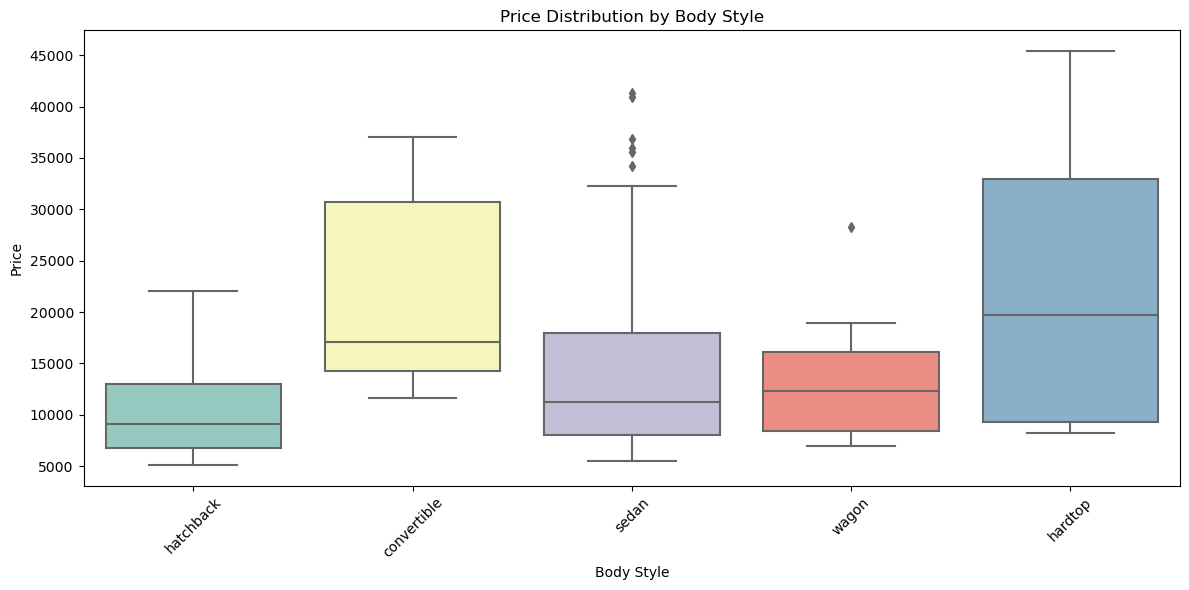

In [119]:
df['price']=pd.to_numeric(df['price'], errors='coerce')
plt.figure(figsize=(12, 6))
sns.boxplot(x='body-style', y='price', data=df, palette='Set3')
plt.xlabel('Body Style')
plt.ylabel('Price')
plt.title('Price Distribution by Body Style')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
### Key Observations

# Vehicles with larger engine sizes tend to have lower fuel efficiency (MPG), indicating a trade-off between power and economy.
# Heavier cars (higher curb weight) are strongly associated with larger engines, suggesting design constraints in performance vehicles.
# Some extreme values (outliers) in engine size and weight may represent luxury or high-performance vehicles.

### Interpretation

# These relationships suggest that fuel efficiency is heavily influenced by engine and weight characteristics.
# For consumers, this highlights the cost trade-off between performance and fuel economy.
# For manufacturers, optimizing engine efficiency while reducing weight could improve overall vehicle performance.